# **XGBoost with Custom Dataset**

Model XGBoost GridSearchCV dan Optuna masih menggunakan dataset yang sama, yakni dataset yang ada di paper. <br>
Pada file ini, akan digunakan dataset hasil engineering kami, yakni pada data\processed\ihsg_processed_2.csv. <br>
Model yang digunakan masih berupa XGBoost Optuna.

In [24]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Load dan Split Data**

Disini, kami akan menggunakan semua fitur yang ada, yakni Close, Return_Target, Return_Lag_1, Return_Lag_2, Return_Lag_3, Return_Lag_5, RSI_14, MACD_Hist, Normalized_ATR, Vol_to_SMA_20, Rolling_Mom_5, Day_of_Week, Is_Month_End <br>
Target nya adalah kolom return_target <br>
Data displit based on 70:15:15 untuk train : val : test <br>
Data tidak displit secara acak, namum split based on time.

In [25]:
processed_file = os.path.join("..", "..", "data", "processed", "ihsg_processed_2.csv")
if not os.path.exists(processed_file):
    raise FileNotFoundError(f"File {processed_file} tidak ditemukan. Jalankan Data_Preparation.ipynb dulu!")

df = pd.read_csv(processed_file, index_col=0, parse_dates=True)
df = df.sort_index()

X = df.drop(columns=['Return_Target'])
y = df['Return_Target']

total_rows = len(df)
train_end = int(total_rows * 0.70)
val_end = train_end + int(total_rows * 0.15)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]
print(f"Data Shapes - Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Data Shapes - Train: (2695, 12), Val: (577, 12), Test: (579, 12)


### **Training Model with Optuna, but Custom Dataset**

Detail nya sama dengan XGBoost Optuna

In [26]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 16),
        'gamma': trial.suggest_float('gamma', 1e-4, 0.1, log=True),
        'random_state': 42,
        'n_jobs': -1
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    return mean_squared_error(y_val, val_preds)

start_time = time.time()
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)
execution_time = time.time() - start_time

print(f"Waktu Eksekusi: {execution_time:.2f} detik")
print(f"Parameter Terbaik: {study.best_params}")

best_params = study.best_params
best_params['random_state'] = 42

best_model = XGBRegressor(**best_params, n_jobs=-1)
best_model.fit(X_train, y_train)

  0%|          | 0/50 [00:00<?, ?it/s]

Waktu Eksekusi: 12.37 detik
Parameter Terbaik: {'n_estimators': 235, 'learning_rate': 0.027575318219892155, 'max_depth': 8, 'gamma': 0.0015462828577162088}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

### **Evaluation and Save**

Evaluasi akan menggunakan 5 metric:
1. MAPE (Mean Absolute Percentage Error): Mengukur seberapa jauh atau akurat sebuah model prediksi dalam memperkirakan suatu nilai, dan hasilnya dinyatakan dalam bentuk persentase.
$$MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

2. MSE (Mean Squared Error): $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

3. RMSE (Root Mean Squared Error): $$RMSE = \sqrt{MSE}$$

4. MAE (Mean Absolute Error): $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

5. Hit Rate: Menghitung seberapa akurat model menebak arah pergerakan pasar.
$$\text{Hit Rate} = \left( \frac{1}{N} \sum_{i=1}^{N} I \left( \text{sgn}(\hat{y}_i) = \text{sgn}(y_i) \right) \right) \times 100\%$$

Keterangan untuk hit rate:
* $N$ = Jumlah total data pengujian yang valid (di mana $y_i \neq 0$).
* $I$ = Fungsi indikator (bernilai 1 jika kondisi di dalamnya benar/sesuai, dan 0 jika salah).
* $\text{sgn}$ = Fungsi *sign* (menghasilkan 1 untuk tren positif/naik, dan -1 untuk tren negatif/turun).
* $\hat{y}_i$ = Nilai *return* prediksi pada waktu ke-$i$.
* $y_i$ = Nilai *return* aktual pada waktu ke-$i$.

In [27]:
import json
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [28]:
test_preds = best_model.predict(X_test)

# MAPE
actual = y_test.values
valid_mape_idx = actual != 0
percentage_errors = np.abs((test_preds[valid_mape_idx] - actual[valid_mape_idx]) / actual[valid_mape_idx]) * 100
mape = np.mean(percentage_errors)
print(f"MAPE: {mape:.4f}%")

# MSE
test_mse = mean_squared_error(y_test, test_preds)
print(f"MSE: {test_mse:.4f}")

# RMSE
test_rmse = np.sqrt(test_mse)
print(f"RMSE: {test_rmse:.4f}")

# MAE
mae = mean_absolute_error(actual, test_preds)
print(f"MAE: {mae:.4f}")

# Hit Rate
arah_prediksi = np.sign(test_preds)
arah_aktual = np.sign(actual)

valid_idx = arah_aktual != 0 
hit_rate = (arah_prediksi[valid_idx] == arah_aktual[valid_idx]).mean() * 100
print(f"Hit Rate: {hit_rate:.4f}%")

# Save metrics dan model
metrics_results = {
    "method": "Custom using Optuna",
    "execution_time_seconds": execution_time,
    "best_params": best_params,
    "best_validation_mse": float(study.best_value),
    "test_mse": float(test_mse),
    "test_rmse": float(test_rmse),
    "test_mae": float(mae),
    "mape": float(mape),
    "hit_rate_percentage": float(hit_rate)
}

with open(os.path.join("..", "..", "outputs", "metrics", "XG_custom_metrics.json"), "w") as f:
    json.dump(metrics_results, f, indent=4)

joblib.dump(best_model, (os.path.join("..", "..", "outputs", "models", "XG_custom_model.pkl")))
print("Model dan metrik berhasil disimpan.")


MAPE: 112.1712%
MSE: 0.0001
RMSE: 0.0099
MAE: 0.0070
Hit Rate: 54.5769%
Model dan metrik berhasil disimpan.


Nah, ada observasi menarik untuk hasil MAPE, MSE, RMSE, dan MAE nya. Hasilnya malah lebih kecil (sangat jauh kecil) dibandingkan dengan XGBoost GridSearchCV dan Optuna. Ini wajar.<br>
Mengapa demikian? Ingat, bahwa untuk custom dataset ini, target_close nya bukan langsung memprediksi harga besok, melainkan persentase perubahan harga ke besok hari nya. Sehingga by default, emang angkanya udah kecil. <br>
Acuan kita disini itu adalah hit rate nya. Perhatikan bahwa hit rate nya melebihi model XGBoost GridSearchCV (46.2%) dan Optuna (46.9%). <br>
Ini merupakan improvement yang lumayan bagus.<br>
(Fun fact: Hit rate 54.7% kalau di quantitative trading, maybe bisa jadi model ini disebut sebagai Alpha).

### **Visualisasi: Actual vs Predicted**

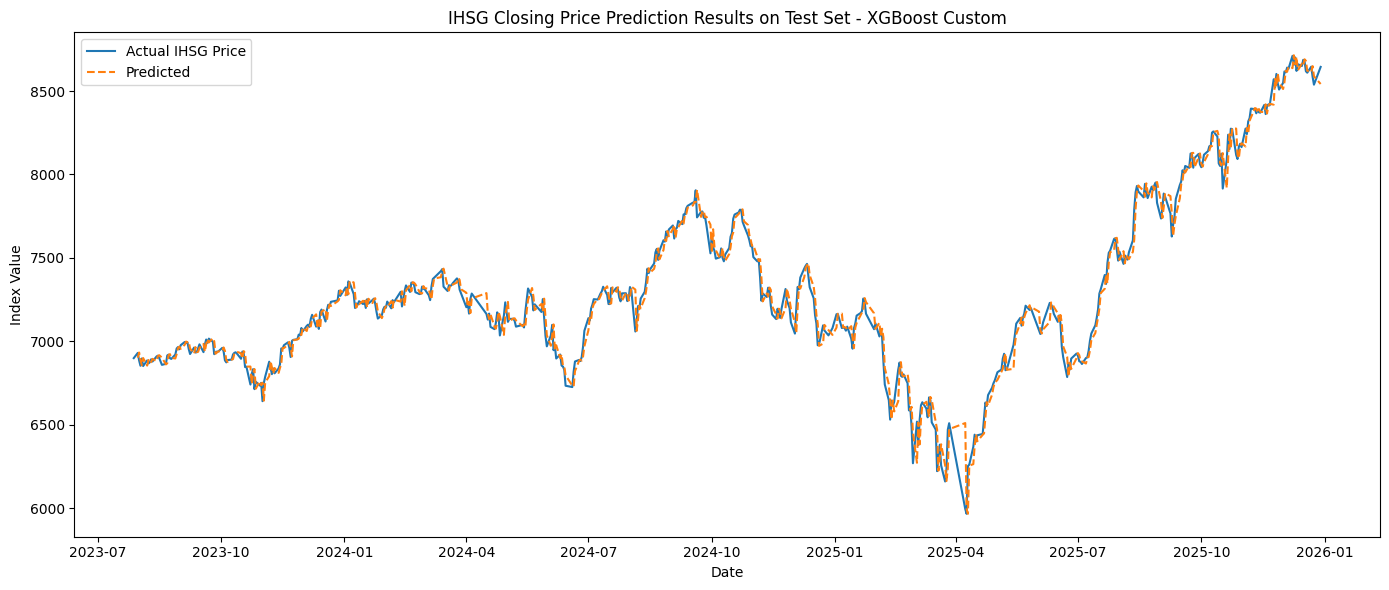

In [29]:
import matplotlib.pyplot as plt

actual_close = df.loc[X_test.index, 'Close']
close_hari_ini = actual_close.shift(1)
predicted_close = close_hari_ini * (1 + test_preds)

plt.figure(figsize=(14, 6))
plt.plot(actual_close.index, actual_close.values, label="Actual IHSG Price", color='#1f77b4', linewidth=1.5)
plt.plot(actual_close.index, predicted_close.values, label="Predicted", color='#ff7f0e', linestyle='--', linewidth=1.5)

plt.title("IHSG Closing Price Prediction Results on Test Set - XGBoost Custom")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join("..", "..", "outputs", "plots", "price_movement_XG_custom.png"), dpi=300)
plt.show()

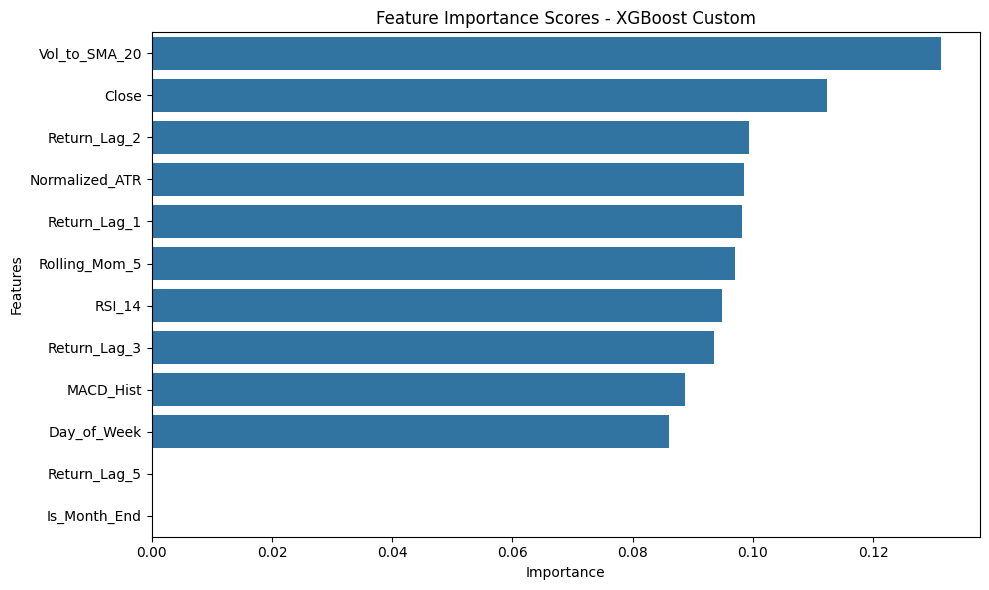

In [30]:
importance_scores = best_model.feature_importances_
importance_df = pd.DataFrame({
    'Features': X_train.columns,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Features', data=importance_df)
plt.title("Feature Importance Scores - XGBoost Custom")
plt.tight_layout()
plt.savefig(os.path.join("..", "..", "outputs", "plots", "features_importance_XG_custom.png"), dpi=300)
plt.show()
